<a href="https://colab.research.google.com/github/Pvidal-1/aprendizaje-automatico-grupo6/blob/main/colab/aprendizaje_automatico_grupo6_s2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Importación de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap

In [2]:
#1.- CARGAR EL DATASET
df = pd.read_csv('https://raw.githubusercontent.com/Pvidal-1/aprendizaje-automatico-grupo6/refs/heads/main/dataset/dataset.csv')

In [ ]:
print(df.info())
print(f"Tamaño : {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

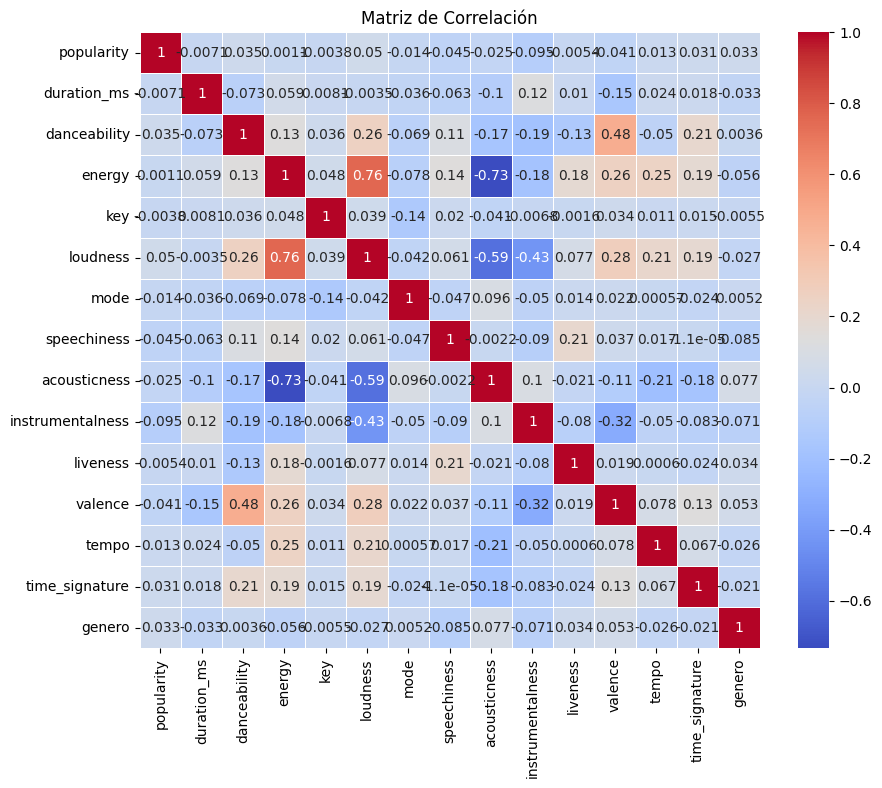

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        113999 non-null  int64  
 4   duration_ms       113999 non-null  int64  
 5   explicit          113999 non-null  bool   
 6   danceability      113999 non-null  float64
 7   energy            113999 non-null  float64
 8   key               113999 non-null  int64  
 9   loudness          113999 non-null  float64
 10  mode              113999 non-null  int64  
 11  speechiness       113999 non-null  float64
 12  acousticness      113999 non-null  float64
 13  instrumentalness  113999 non-null  float64
 14  liveness          113999 non-null  float64
 15  valence           113999 non-null  float64
 16  tempo             113999 

In [3]:
#2.- ANALISIS EXPLORATORIO DEL DATASET
#2.1 ELIMINACION DE VARIABLES QUE NO SE VAN A UTILIZAR PORQUE GENERAN RUIDO
#EXPLICACIÓN: UNNAMED:0 ES UN IDENTIFICADOR DE REGISTRO Y TRACK_ID ES UN IDENTIFICADOR ALFANUMERICO, NO SE NECESITAN
df_exploratorio = df.drop(columns=["Unnamed: 0","track_id"])
#2.2 ELIMINACION DE POSIBLES NULOS
df_exploratorio = df_exploratorio.dropna()
#AL FINAL ME QUEDO CON 18 VARIABLES Y 1 CLASE O VARIABLE OBJETIVO QUE ES LA COLUMNA track_genre
#2.3 VISUALIZACION DE RELACIONES CON GRAFICOS, MATRIZ DE CORRELACION
#CODIFICO LA VARIABLE OBJETIVO O CLASE EN UNA NUEVA COLUMNA LLAMADA GENERO
df_exploratorio['genero'] = LabelEncoder().fit_transform(df_exploratorio['track_genre'])
plt.figure(figsize=(10, 8))
# Seleccionamos solo columnas numéricas para la correlación
numeric_df = df_exploratorio.select_dtypes(include=['int64', 'float64'])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()
#ANÁLISIS DE LA MATRIZ DE CORRELACIÓN
#energy y loudness: TIENEN LA CORRELACIÓN MÁS ALTA 0.76, LAS CANCIONES MÁS ENERGÉTICAS TIENDEN A SER MÁS RUIDOSAS
#acousticness y energy: TIENEN UNA CORRELACIÓN MUY NEGATIVA -0.73, CUANDO MÁS ACÚSTICA ES UNA CANCIÓN MENOS ENERGÉTICA SUELE SER
#danceability y valence: TIENE UNA CORRELACIÓN DE 0.48, LAS CANCIONES MÁS BAILABLES SUELEN SER MÁS ALEGRES
#popularity: TIENE CORRELACIONES MUY BAJAS CON CASI TODAS LAS VARIABLES, LA POPULARIDAD NO PARECE TENER RELACIÓN CON NINGUNA CARACTERÍSTICA TÉCNICA DE LA CANCIÓN
#key: TIENE UNA CORRELACIÓN MUY BAJA CON CASI TODAS LAS VARIABLES Y PRACTICAMENTE INSIGNIFICANTE CON EL GENERO
#CONCLUSION:
#AUNQUE HAY VARIABLES COMO POPULARITY Y TIME_SIGNATURE QUE TIENEN CORRELACIONES MUY BAJAS, PODRÍAN SER ÚTILES COMBINADAS CON LAS OTRAS VARIABLES
#TAMBIEN QUITO LA COLUMNA GENERO YA QUE SOLO SE USÓ PARA LA MATRIZ DE CORRELACIÓN
df_exploratorio = df_exploratorio.drop(columns=["genero"])
#IMPRIMO LA INFORMACIÓN DEL DATASET FINAL QUE SE UTILIZARÁ - 18 VARIABLES Y 1 CLASE O VARIABLE OBJETIVO (track_genre)
print(df_exploratorio.info())

In [4]:
#3 PREPROCESAMIENTO
#3.1 COMO EL DATASET ORIGINAL TIENE 114000 FILAS, LO REDUCIRÉ A 5000 PARA QUE LAS PRUEBAS SE EJECUTEN MÁS RÁPIDO
#df_aleatorio = df_exploratorio.sample(n=5000, random_state=42) #SERAN ESCOGIDOS DE MANERA ALEATORIA
df_aleatorio =  df_exploratorio[:5000] #SELECCIONO LOS PRIMEROS 5000 PARA LIMITAR UN POCO LAS CANTIDAD DE CLASES A PREDECIR (ORIGINALMENTE HAY MÁS DE 100)
print(f"Tamaño del subdataset aleatorio : {df_aleatorio.shape}")
#3.2 SEPARAR VARIABLES DE CLASE O VARIABLE OBJETIVO X E Y
X = df_aleatorio.drop(columns=["track_genre"]) #A LA VARIABLE X LE QUITO LA COLUMNAS TRACK_GENRE QUE CORRESPONDE A LA CLASE O VARIABLE OBJETIVO QUE SE VA ANALIZAR
Y = df_aleatorio["track_genre"]
#3.3 CODIFICAR LAS VARIABLES CATEGORICAS EN X SI EXISTIERAN
X = pd.get_dummies(X)
#CODIFICAR LA VARIABLE OBJETIVO O CLASES
le = LabelEncoder()
Y_codificado = le.fit_transform(Y)
#3.4 ESCALADO DE VARIABLES O CARACTERISTICAS X
scaler = StandardScaler()
X_scalado = scaler.fit_transform(X)
#3.5 DIVISIÓN DEL CONJUNTO DE ENTRENAMIENTO Y PRUEBA
#EXPLICACIÓN DE VARIABLES SELECCIONADAS:
#test_size=0.2: El 20% de los datos serán usados para prueba.
#stratify=Y: garantiza que la proporción de clases (track_genre) sea igual en entrenamiento y prueba.
X_train, X_test, Y_train, Y_test = train_test_split(X_scalado, Y_codificado, test_size=0.2, random_state=42,stratify=Y_codificado)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del subdataset aleatorio : (5000, 19)
Tamaño del conjunto de entrenamiento: (4000, 7656)
Tamaño del conjunto de prueba: (1000, 7656)


MODELO 1: ARBOL DE DECISIÓN

MATRIZ DE CONFUSIÓN (ARBOL DE DECISION):


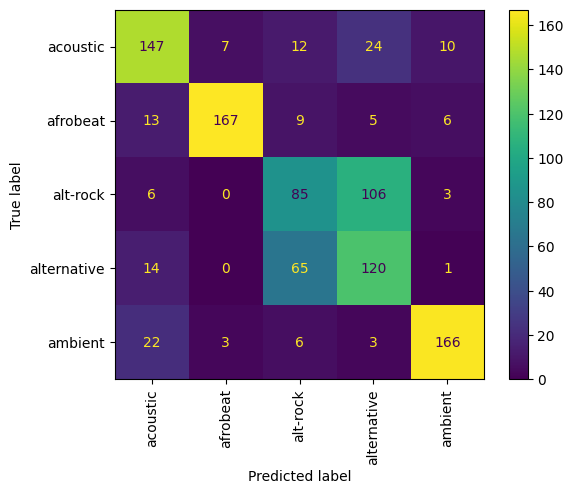

MÉTRICAS DEL MODELO 1 (ARBOL DE DECISIÓN)
Precisión: 0.7018081966371774
Recall: 0.6849999999999999
F1-score: 0.6904668808598403

Classification Report:
               precision    recall  f1-score   support

    acoustic       0.73      0.73      0.73       200
    afrobeat       0.94      0.83      0.89       200
    alt-rock       0.48      0.42      0.45       200
 alternative       0.47      0.60      0.52       200
     ambient       0.89      0.83      0.86       200

    accuracy                           0.69      1000
   macro avg       0.70      0.68      0.69      1000
weighted avg       0.70      0.69      0.69      1000



In [ ]:
#4 IMPLEMENTACIÓN DE CLASIFICADORES: ENTRENAR Y EVALUAR
#4.1 ENTRENAR EL MODELO USANDO ARBOL DE DECISION
#clf_tree = DecisionTreeClassifier(random_state=42)
clf_tree = DecisionTreeClassifier(criterion= 'entropy', max_depth= 10, max_features= None, min_samples_leaf= 1, min_samples_split= 2, random_state=42)
clf_tree.fit(X_train, Y_train)
#PREDICCIONES
y_pred_tree = clf_tree.predict(X_test)

#UTIL#IZAR GRIDSEARCHCV PARA ENCONTRAR LA MEJOR COMBINCACIÓN DE PARÁMETROS, LA QUE TENGA MEJOR ACCURACY
#param_grid = {
#    'criterion': ['gini', 'entropy', 'log_loss'],
#    'max_depth': [None, 5, 10, 20, 30],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 4],
#    'max_features': [None, 'sqrt', 'log2']
#}
#CONFIGURAR LA BÚSQUEDA
#grid_search = GridSearchCV(estimator=clf_tree, param_grid=param_grid,cv=5, n_jobs=-1, verbose=1, scoring='accuracy')
#EJECUTAR LA BÚSQUEDA Y ENTRENAMIENTO
#grid_search.fit(X_train, Y_train)
#MEJOR MODELO ENCONTRADO
#best_tree = grid_search.best_estimator_
#print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA EL MODELO ARBOL DE DECISIÓN:", grid_search.best_params_)
#MEJORES HIPERPARÁMETROS ENCONTRADOS PARA EL MODELO ARBOL DE DECISIÓN: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
# Predicción usando el mejor modelo
#y_pred_tree = best_tree.predict(X_test)

print("MODELO 1: ARBOL DE DECISIÓN")
print("\nMATRIZ DE CONFUSIÓN (ARBOL DE DECISION):")
#Matriz de Confusión
disp = ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_tree, display_labels=le.classes_)
disp.ax_.set_xticklabels(le.classes_, rotation=90)
plt.show()

precision = precision_score(Y_test, y_pred_tree, average='macro')  # o 'weighted' o 'micro'
recall = recall_score(Y_test, y_pred_tree, average='macro')
f1 = f1_score(Y_test, y_pred_tree, average='macro')
print("="*50)
print("MÉTRICAS DEL MODELO 1 (ARBOL DE DECISIÓN)")
print("Precisión:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("="*50)
print("\nClassification Report:\n", classification_report(Y_test, y_pred_tree, target_names=le.classes_))


Árbol de Decisión: Accuracy promedio = 0.616, Desviación Estándar = 0.074
SVC: Accuracy promedio = 0.654, Desviación Estándar = 0.042
Random Forest: Accuracy promedio = 0.669, Desviación Estándar = 0.037


<ipython-input-14-66515af3d1f1>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Modelo', y='Accuracy Promedio', data=cv_df, palette='viridis')


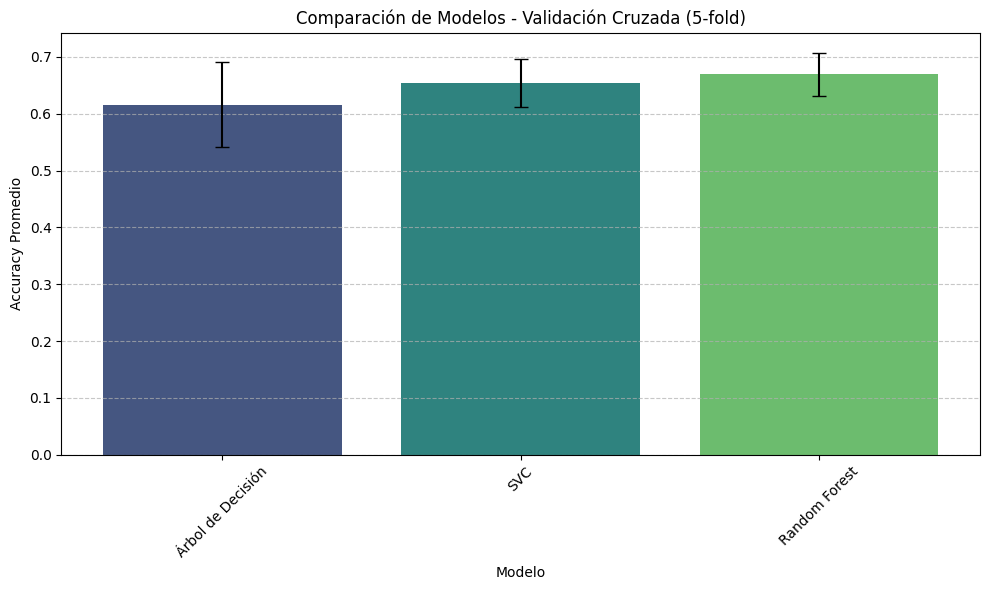

In [14]:
#VALIDACION CRUZADA

cv_results = [] # Lista para almacenar resultados
models = {
    'Árbol de Decisión': DecisionTreeClassifier(criterion= 'entropy', max_depth= 10, max_features= None, min_samples_leaf= 1, min_samples_split= 2, random_state=42),
    'SVC': SVC(kernel='linear', C=10 , random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth= None, min_samples_leaf= 1, min_samples_split= 2, random_state=42)
}

scores = cross_val_score(models['Árbol de Decisión'],X_scalado, Y_codificado, cv=5, scoring='accuracy')
print(f"Árbol de Decisión: Accuracy promedio = {scores.mean():.3f}, Desviación Estándar = {scores.std():.3f}")
cv_results.append({ 'Modelo': 'Árbol de Decisión', 'Accuracy Promedio': scores.mean(), 'Desviación Estándar': scores.std(), 'Scores': scores})

scores = cross_val_score(models['SVC'],X_scalado, Y_codificado, cv=5, scoring='accuracy')
print(f"SVC: Accuracy promedio = {scores.mean():.3f}, Desviación Estándar = {scores.std():.3f}")
cv_results.append({ 'Modelo': 'SVC', 'Accuracy Promedio': scores.mean(), 'Desviación Estándar': scores.std(), 'Scores': scores})

scores = cross_val_score(models['Random Forest'],X_scalado, Y_codificado, cv=5, scoring='accuracy')
print(f"Random Forest: Accuracy promedio = {scores.mean():.3f}, Desviación Estándar = {scores.std():.3f}")
cv_results.append({ 'Modelo': 'Random Forest', 'Accuracy Promedio': scores.mean(), 'Desviación Estándar': scores.std(), 'Scores': scores})

#CONCLUSIONES
#PROBÉ DIFEFERENTES CONFIGURACIONES PARA SVC Y RANDOM FOREST
#TODAS ME DAN UN ACCURACY QUE NO SUPERA EL 0.6, EL SVC DEMORA MUCHO EN PROCESAR Y EL MEJOR DE TODOS
cv_df = pd.DataFrame(cv_results)[['Modelo', 'Accuracy Promedio', 'Desviación Estándar']]
#Graficar Comparación de Validación Cruzada
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Modelo', y='Accuracy Promedio', data=cv_df, palette='viridis')
# Agregar barras de error usando las posiciones correctas del eje x
x_coords = [p.get_x() + p.get_width() / 2 for p in barplot.patches]
plt.errorbar(x=x_coords, y=cv_df['Accuracy Promedio'], yerr=cv_df['Desviación Estándar'], fmt='none', color='black', capsize=5)
plt.title('Comparación de Modelos - Validación Cruzada (5-fold)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# === Modelo 2: SVM con RandomizedSearchCV
svc = SVC()
param_dist_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # solo se usará si kernel='poly'
}
svc_random = RandomizedSearchCV(svc, param_distributions=param_dist_svc,
                                n_iter=3, #numero de iteracciones 3
                                cv=3, #Validacion Cruzada 3 folds
                                verbose=1, n_jobs=-1, random_state=42, scoring='accuracy')
svc_random.fit(X_train, Y_train)
svc_best = svc_random.best_estimator_
#MEJOR MODELO ENCONTRADO
print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA EL MODELO SVC:", svc_random.best_params_)
Y_pred_svc = svc_best.predict(X_test)

print("="*50)
print("MÉTRICAS DEL MODELO 2 (SVM)")
print("Precisión:", accuracy_score(Y_test, Y_pred_svc))
print("Recall:", recall_score(Y_test, Y_pred_svc, average='macro'))
print("F1-score:", f1_score(Y_test, Y_pred_svc, average='macro'))
print("="*50)
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_svc, target_names=le.classes_))

MEJORES HIPERPARÁMETROS ENCONTRADOS PARA EL MODELO SVC: {'kernel': 'linear', 'gamma': 'scale', 'degree': 3, 'C': 100}
MÉTRICAS DEL MODELO 2 (SVM)
Precisión: 0.675
Recall: 0.6749999999999999
F1-score: 0.6970697035524809

Classification Report:
               precision    recall  f1-score   support

    acoustic       1.00      0.80      0.89       200
    afrobeat       0.99      0.83      0.91       200
    alt-rock       0.35      0.39      0.37       200
 alternative       0.32      0.42      0.36       200
     ambient       0.99      0.94      0.96       200

    accuracy                           0.68      1000
   macro avg       0.73      0.67      0.70      1000
weighted avg       0.73      0.68      0.70      1000



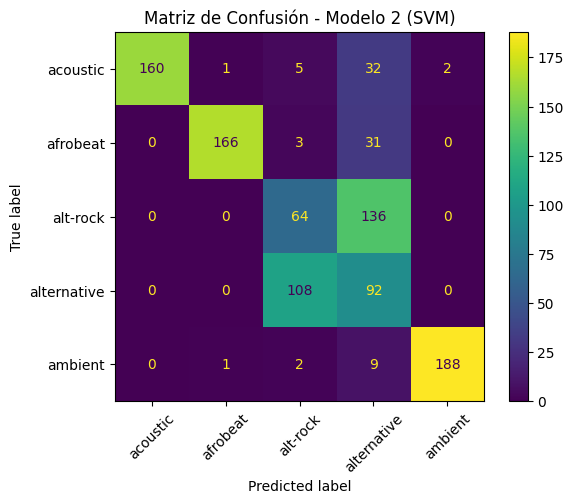

In [ ]:
# Matriz de confusión para el Modelo 2 (SVM)
cm_svc = confusion_matrix(Y_test, Y_pred_svc)
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=le.classes_)
disp_svc.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Modelo 2 (SVM)")
plt.grid(False)
plt.show()


In [12]:
# === Modelo 3: Random Forest con RandomizedSearchCV
rf = RandomForestClassifier(random_state=42)
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],       # árboles
    'max_depth': [None, 10, 20, 30],           # profundidad del árbol
    'min_samples_split': [2, 5, 10],           # mínimo de muestras para dividir
    'min_samples_leaf': [1, 2, 4],             # mínimo de muestras en una hoja
    'max_features': ['sqrt', 'log2', None],    # número de features usadas por split
    'bootstrap': [True, False]                 # si usar muestreo con reemplazo
}
rf_random = RandomizedSearchCV(rf, param_distributions=param_dist_rf, n_iter=4, cv=3, verbose=1, n_jobs=-1,random_state=42,scoring='accuracy')
rf_random.fit(X_train, Y_train)
rf_best = rf_random.best_estimator_
print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA EL MODELO RANDOM FOREST:", rf_random.best_params_)
Y_pred_rf = rf_best.predict(X_test)

print("="*50)
print("MÉTRICAS DEL MODELO 3 (RANDOM FOREST)")
print("Precisión:", accuracy_score(Y_test, Y_pred_rf))
print("Recall:", recall_score(Y_test, Y_pred_rf, average='macro'))
print("F1-score:", f1_score(Y_test, Y_pred_rf, average='macro'))
print("="*50)
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_rf, target_names=le.classes_))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
MEJORES HIPERPARÁMETROS ENCONTRADOS PARA EL MODELO RANDOM FOREST: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
MÉTRICAS DEL MODELO 3 (RANDOM FOREST)
Precisión: 0.703
Recall: 0.7030000000000001
F1-score: 0.7016656311772713

Classification Report:
               precision    recall  f1-score   support

    acoustic       0.90      0.85      0.88       200
    afrobeat       0.90      0.98      0.94       200
    alt-rock       0.36      0.37      0.36       200
 alternative       0.39      0.38      0.38       200
     ambient       0.96      0.93      0.94       200

    accuracy                           0.70      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.70      0.70      0.70      1000



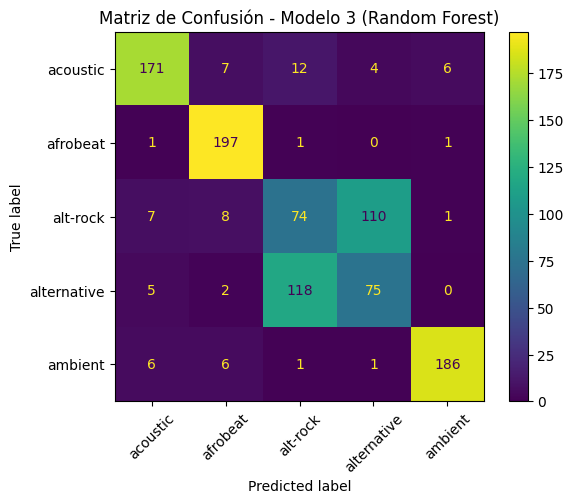

In [13]:
# Matriz de confusión para el Modelo 3 (Random Forest)
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Modelo 3 (Random Forest)")
plt.grid(False)
plt.show()
